# EXERCISE 1

## Download and prepare our dataset

In [5]:
# Import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import gzip
import tarfile
from sklearn.datasets import load_files

C:\Users\joker\AppData\Local\Temp\ipykernel_8660\3477612667.py:3: DeprecationWarning: 
Pyarrow will become a required dependency of pandas in the next major release of pandas (pandas 3.0),
(to allow more performant data types, such as the Arrow string type, and better interoperability with other libraries)
but was not found to be installed on your system.
If this would cause problems for you,
please provide us feedback at https://github.com/pandas-dev/pandas/issues/54466
        
  import pandas as pd


### Download our dataset (optional-is downloaded from the previous project)

In [6]:
# # # Download Data when in google Collab
# !wget https://ai.stanford.edu/~amaas/data/sentiment/aclImdb_v1.tar.gz
# !tar xvzf aclImdb_v1.tar.gz > /dev/null && rm -rf aclImdb_v1.tar.gz # Extract contents and delete the zipped file

### Load our files locally from the previous project

In [7]:
from sklearn.datasets import load_files

train_path = r'C:\1. Python\MLP_Classifier\aclImdb\train'
test_path = r'C:\1. Python\MLP_Classifier\aclImdb\test'

movies_train = load_files(container_path=train_path, encoding="utf-8")
movies_test = load_files(container_path=test_path, encoding="utf-8")
print(type(movies_train))

<class 'sklearn.utils._bunch.Bunch'>


In [8]:
# Transform train dataset into a dataframe
data_train = {'reviews': movies_train.data, 'sentiment': movies_train.target}
df_train = pd.DataFrame(data_train)

# Transform test dataset into a dataframe
data_test = {'reviews': movies_test.data, 'sentiment': movies_test.target}
df_test = pd.DataFrame(data_test)

del movies_train, movies_test # free memory

print(df_train.iloc[:10])
print('----------------------------------------------------------------------------------------')
print(df_test.iloc[:10])

                                             reviews  sentiment
0  Full of (then) unknown actors TSF is a great b...          2
1  Amount of disappointment I am getting these da...          2
2  The future, we are told, are what we make of i...          2
3  Dan Katzir has produced a wonderful film that ...          1
4  If you want Scream or anything like the big-st...          1
5  Although its mold of 1949 appears somewhat mel...          2
6  Gloomy Sunday - Ein Lied von Liebe und Tod dir...          2
7  This movie was ridiculous. The plot is complet...          2
8  Why was this movie made? No doubt to sucker in...          2
9  Outlandish premise that rates low on plausibil...          0
----------------------------------------------------------------------------------------
                                             reviews  sentiment
0  Don't hate Heather Graham because she's beauti...          1
1  I don't know how this movie has received so ma...          0
2  I caught thi

In [9]:
# Drop rows where 'sentiment' is 2 from train & test sets
df_train = df_train[df_train['sentiment'] != 2]
df_test = df_test[df_test['sentiment'] != 2]


df_test = df_test.reset_index(drop=True)
df_train = df_train.reset_index(drop=True)

# Define the train dataset with 5000 rows by test set
df_train = pd.concat([df_train, df_test[:5000]])

print(f'The size of training set is: {len(df_train)}')
print(f'The size of test set is: {len(df_test[5000:])}')

The size of training set is: 30000
The size of test set is: 20000


In [10]:
from sklearn.utils import shuffle

# Shuffle dataframes because they are sorted.
df_train = shuffle(df_train)
df_train.reset_index(inplace=True, drop=True)
df_test = shuffle(df_test)
df_test.reset_index(inplace=True, drop=True)

df_train.head()

,reviews,sentiment
0,"this film tries to be immensely clever, and Ta...",0
1,I think that you can not imagine how these peo...,0
2,Have you ever wished that you could escape you...,1
3,"About halfway through, I realized I didn't car...",0
4,Why take a show that millions of us watched an...,0


In [11]:
X_train = df_train.reviews
y_train = df_train.sentiment

In [12]:
# Split dev and test data
from sklearn.model_selection import train_test_split

X_dev, X_test, y_dev, y_test = train_test_split(df_test.reviews[5000:], df_test.sentiment[5000:], test_size=0.5, random_state=42)
print(f"Number of observations in dev set: {X_dev.shape[0]}")
print(f"Number of observations in test set: {X_test.shape[0]}")

Number of observations in dev set: 10000
Number of observations in test set: 10000


### Plot the length of each class(pos or neg) for each set

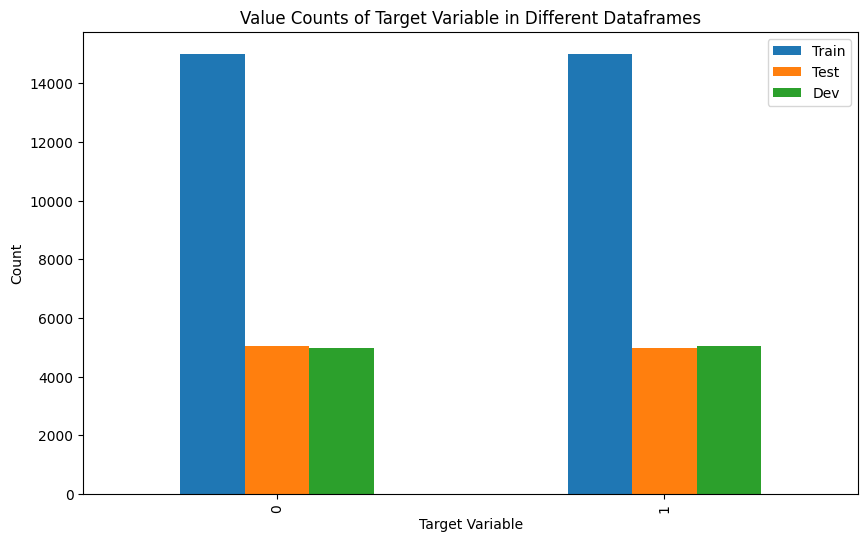

In [13]:

# Count the values of the ground truth (sentiments)
train_counts = y_train.value_counts()
test_counts = y_test.value_counts()
dev_counts = y_dev.value_counts()


# Create a DataFrame with the counts
counts_df = pd.DataFrame({'Train': train_counts, 'Test': test_counts, 'Dev': dev_counts})

# Plot the bar plot
counts_df.plot(kind='bar', figsize=(10, 6))
plt.title('Value Counts of Target Variable in Different Dataframes')
plt.xlabel('Target Variable')
plt.ylabel('Count')
plt.show()


### Plot the size of each text for each set

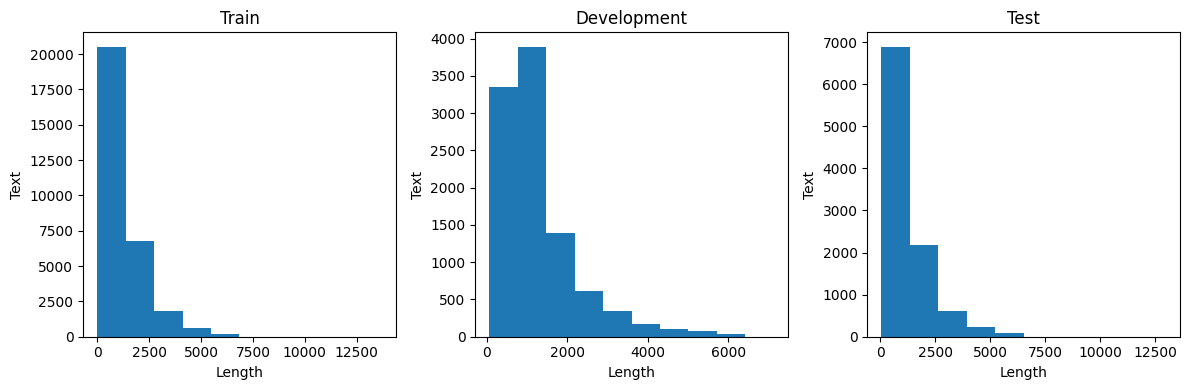

In [14]:
# Function to plot text lengths
def plot_text_lengths(ax, texts, title):
    text_lengths = [len(text) for text in texts]
    ax.hist(text_lengths)
    ax.set_xlabel('Length')
    ax.set_ylabel('Text')
    ax.set_title(title)

# Create subplots
fig, (ax1, ax2, ax3) = plt.subplots(1,3, figsize=(12, 4))

# Plot for texts1
plot_text_lengths(ax1, X_train, 'Train')

# Plot for texts2
plot_text_lengths(ax2, X_dev, 'Development')

plot_text_lengths(ax3, X_test, 'Test')

# Adjust layout for better spacing
plt.tight_layout()

# Show the plots
plt.show()

# Preprocessing

* Replace non-word characters and numbers with empty string.
* Substitute multiple spaces with single space.
* Convert to lowercase.
* Remove stop words.
* Stemming with WordNetLemmatizer.

In [15]:
# Imports we need for preprocessing
import re
import nltk
nltk.download('punkt')
nltk.download('wordnet')
nltk.download('stopwords')
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer
from nltk.stem import PorterStemmer

stemmer = WordNetLemmatizer()

# Import stop words for preprocessing
from nltk.corpus import stopwords
stop_words = set(stopwords.words('english'))

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\joker\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\joker\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\joker\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [16]:
import re
def preprocess(contents):

    """
        Preprocesses a list of texts by removing non-word characters, single characters, extra spaces,
    converting to lowercase, splitting into words, lemmatizing, and reconstructing the documents.
    :param contents: A list of texts to be preprocessed
    :return: A Pandas Series containing preprocessed documents.
    """


    docs = []

    for doc in contents:

        # Delete all the non-word characters for the data frame
        document = re.sub(r'[^a-zA-Z\s]', '', str(doc))

        document = re.sub(r'br', '', str(document))

        # Split the document based on whitespaces (--> List of words)
        word_list = document.split()

        word_list = [word.lower() for word in word_list if word.lower() not in (stop_words)]

        # Lemmatization
        word_list = [stemmer.lemmatize(word) for word in word_list]

        # Reconstruct the document by joining the words on each whitespace
        document = ' '.join(word_list)

        # Append all documents into a list 'docs'
        docs.append(document)
    return pd.Series(docs)

In [17]:
# Preprocess texts
X_train = preprocess(X_train)
X_dev = preprocess(X_dev)
X_test = preprocess(X_test)

### Example

In [18]:
# Example of a preprocessed text
print(f'The non processed text:\n {df_train.reviews.iloc[10]}')
print('------------------------------------------------------------------------------------')
print('VS')
print('------------------------------------------------------------------------------------')
print(f'The processed text:\n {X_train[10]}')

The non processed text:
 This film captures the true struggle with identity that is ongoing in our teenage years. It is really moving and it feels strangely like a documentary-not contrived but very real. It is very interesting and unsettling
------------------------------------------------------------------------------------
VS
------------------------------------------------------------------------------------
The processed text:
 film capture true struggle identity ongoing teenage year really moving feel strangely like documentarynot contrived real interesting unsettling


## Baseline Model (LogisticRegression)

* The dataset we are using in this notebook was used in exercise 9 part 3

* So, we know that TF-IDF with SVD provide the best results for the baseline model.



# TF-IDF Vectorization


In [19]:
from sklearn.feature_extraction.text import TfidfVectorizer

# Use unigram & bi-gram tf*idf features
vectorizer = TfidfVectorizer(ngram_range=(1, 3),
                             max_features = 5000, sublinear_tf=True)

X_train_tfidf = vectorizer.fit_transform(X_train)
X_dev_tfidf = vectorizer.transform(X_dev)
X_test_tfidf = vectorizer.transform(X_test)

print(X_train_tfidf.shape, type(X_train_tfidf))

(30000, 5000) <class 'scipy.sparse._csr.csr_matrix'>


## Dimensionality reduction via SVD method

In [20]:
# Reduce dimensionality using SVD 5000 --> 500
from sklearn.decomposition import TruncatedSVD

svd = TruncatedSVD(n_components=1000, random_state=4321)
X_train_svd = svd.fit_transform(X_train_tfidf)
X_dev_svd = svd.transform(X_dev_tfidf)
X_test_svd = svd.transform(X_test_tfidf)

print(X_train_svd.shape, type(X_train_svd))

(30000, 1000) <class 'numpy.ndarray'>


### (Baseline 1) Build a Logistic Regression Baseline


In [21]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report
from sklearn.metrics import precision_recall_curve, auc
clf = LogisticRegression()
clf.fit(X_train_svd.tolist(), y_train)

# Validation set prediction
predictions = clf.predict(X_dev_svd.tolist())
print(f"\t\tClassification Report for developement set:\n\n {classification_report(y_dev, predictions)}")

# Test set prediction
predictions2 = clf.predict(X_test_svd.tolist())
print(f"\n\n\t\tClassification Report for testing set:\n\n {classification_report(y_test, predictions2)}")



		Classification Report for developement set:

               precision    recall  f1-score   support

           0       0.90      0.88      0.89      4957
           1       0.88      0.90      0.89      5043

    accuracy                           0.89     10000
   macro avg       0.89      0.89      0.89     10000
weighted avg       0.89      0.89      0.89     10000



		Classification Report for testing set:

               precision    recall  f1-score   support

           0       0.90      0.88      0.89      5032
           1       0.88      0.90      0.89      4968

    accuracy                           0.89     10000
   macro avg       0.89      0.89      0.89     10000
weighted avg       0.89      0.89      0.89     10000



### Convert labels to 1-hot vectors(optinal for binary classification)

In [22]:
import tensorflow as tf

y_train_1_hot = tf.keras.utils.to_categorical(y_train, num_classes=2)
y_dev_1_hot = tf.keras.utils.to_categorical(y_dev, num_classes=2)


print(f"Y_train 1 hot: {y_train_1_hot}", "\n\n",f"Y_dev 1 hot:{y_dev_1_hot}")


Y_train 1 hot: [[1. 0.]
 [1. 0.]
 [0. 1.]
 ...
 [1. 0.]
 [1. 0.]
 [0. 1.]] 

 Y_dev 1 hot:[[0. 1.]
 [0. 1.]
 [1. 0.]
 ...
 [1. 0.]
 [0. 1.]
 [0. 1.]]


### (Baseline 2) Build the MLP model of exercise 9 Part 3

In [23]:
# Import libraries
import keras
from keras.layers import InputLayer
from keras.layers import Activation, Dropout, Dense, Input,BatchNormalization, Flatten, Embedding
from keras.models import Model, Sequential
from keras.optimizers import Adam
from keras.preprocessing.text import Tokenizer
from keras.preprocessing.sequence import pad_sequences
from keras.callbacks import ModelCheckpoint, EarlyStopping, Callback
from sklearn.preprocessing import LabelBinarizer
from sklearn.model_selection import train_test_split


def create_MLP_model(input_dim, activation_dense_layers):
    """
    Create a deep feed forward network with Dense layers
    Add techniques such as dropout and Batch Normalization
    :param input_dum: integer for the dimension of the input layer)
    :param  activation_dense_layers: string, for the activation function
    :return: class keras.src.engine

    """
    mlp_model = Sequential()

    # Add InputLayer with specified input dimension
    mlp_model.add(InputLayer(input_shape=(input_dim,)))

    # First Layer
    mlp_model.add(Dense(128, activation='relu'))
    mlp_model.add(BatchNormalization())
    mlp_model.add(Dropout(0.4))
    # Second Layer
    mlp_model.add(Dense(512, activation='relu'))
    mlp_model.add(BatchNormalization())
    mlp_model.add(Dropout(0.5))
    # Third Layer
    mlp_model.add(Dense(128, activation='relu'))
    mlp_model.add(BatchNormalization())
    mlp_model.add(Dropout(0.4))
    # Output Layer
    mlp_model.add(Dense(1, activation='sigmoid'))


    return mlp_model


### Custom Keras callback for calculating F1, precision, recall at the end of each epoch

In [24]:
class Metrics(Callback):
    def __init__(self, valid_data):
        super(Metrics, self).__init__()
        self.validation_data = valid_data

    def on_epoch_end(self, epoch, logs=None):
        logs = logs or {}
        val_predict_proba = self.model.predict(self.validation_data[0])
        val_predict = (val_predict_proba > 0.5).astype(int)  # Convert probabilities to classes

        val_targ = self.validation_data[1]

        _val_f1 = f1_score(val_targ, val_predict, average="binary")
        _val_recall = recall_score(val_targ, val_predict, average="binary")
        _val_precision = precision_score(val_targ, val_predict, average="binary")

        logs['val_f1'] = _val_f1
        logs['val_recall'] = _val_recall
        logs['val_precision'] = _val_precision
        print(" — val_f1: %.3f — val_precision: %.3f — val_recall: %.3f" % (_val_f1, _val_precision, _val_recall))


In [25]:
from sklearn.metrics import f1_score, recall_score, precision_score

adam = Adam(learning_rate = 0.00004)

mlp = create_MLP_model(X_train_svd.shape[1],'relu')
mlp.compile(
    loss='binary_crossentropy',
    optimizer=adam,
    metrics=["accuracy"]
    )

# Build the model and print the structure of our model before training
mlp.build(X_train_svd.shape[1])  # We need to build our model in order to print the structure
print(mlp.summary())

# Add an early stopping callback to stop the epochs when we catch the best validation loss
early_stopping_callback = EarlyStopping(
    monitor='val_loss',  # Monitor validation loss for early stopping
    patience=10,           # Number of epochs with no improvement after which training will be stopped
    restore_best_weights=True  # Restore best model weights when early stopping is triggered
)

# Callback to save the Keras model or model weights at some frequency.
MLP_checkpoint = ModelCheckpoint(
    'checkpoints/weights.hdf5',
    monitor='val_loss',
    mode='min',
    verbose=2,
    save_best_only=True,
    save_weights_only=True
    )

# Start our training
history = mlp.fit(
    X_train_svd,
    y_train,
    validation_data=(X_dev_svd, y_dev),
    batch_size=128,
    epochs=65,
    shuffle=True,
    callbacks=[early_stopping_callback]
)


Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense (Dense)               (None, 128)               128128    
                                                                 
 batch_normalization (Batch  (None, 128)               512       
 Normalization)                                                  
                                                                 
 dropout (Dropout)           (None, 128)               0         
                                                                 
 dense_1 (Dense)             (None, 512)               66048     
                                                                 
 batch_normalization_1 (Bat  (None, 512)               2048      
 chNormalization)                                                
                                                                 
 dropout_1 (Dropout)         (None, 512)               

In [26]:
# Evaluate in test set
evaluation = mlp.evaluate(X_test_svd, y_test)

print('Test Set Evaluation:')
print(f"The loss of the test set is:{evaluation[0]: .3f},\nThe accuracy of the test set is:{evaluation[1]*100: .3f}%")

313/313 [==============================] - 1s 2ms/step - loss: 0.2634 - accuracy: 0.8929
Test Set Evaluation:
The loss of the test set is: 0.263,
The accuracy of the test set is: 89.290%


In [27]:
average_length = df_train.reviews.apply(len).mean()
print("Average length of reviews:", average_length)

Average length of reviews: 1320.13


### CHECK THE SEQUENCE LENGTH

We are going to check the length of each review and drop the reviews that exceed the max sequence length that we will add to our RNN model.

In [29]:
def no_of_words(text):
  
    return len(str(text).split())

# Apply the function to 'text' column
df_train['word_count'] = df_train['reviews'].apply(lambda x: no_of_words(x) if isinstance(x, str) else 0)

print(f'The total length of reviews for class 0 is: {len(df_train.word_count[df_train.sentiment==0]):.0f}')
print(f'The mean length of each review for class 0 is: {np.mean(df_train.word_count[df_train.sentiment==0]):.2f}')
print('-----------------------------------------------------------------------------------------------------------')
print(f'The total length of reviews for class 1 is: {len(df_train.word_count[df_train.sentiment==1]): .0f}')
print(f'The mean length of each review for class 1 is: {np.mean(df_train.word_count[df_train.sentiment==1]):.2f}')


The total length of reviews for class 0 is: 14996
The mean length of each review for class 0 is: 230.03
-----------------------------------------------------------------------------------------------------------
The total length of reviews for class 1 is:  15004
The mean length of each review for class 1 is: 235.84


### LETS KEEP THE REVIEWS WITH MAX LENGTH=164

In [31]:
print(len(df_train[df_train.word_count<=512]))

df_train_clean = df_train[df_train.word_count<=512]

print(df_train_clean.sample(10))
print('-------------------------------------------------------------')
print(f'The total length of reviews for class 0 is: {len(df_train_clean[df_train_clean.sentiment==0]):.0f}')
print(f'The total length of reviews for class 1 is: {len(df_train_clean[df_train_clean.sentiment==1]):.0f}')

27744
                                                 reviews  sentiment  \
16609  People call a 976 "party line" to talk dirty t...          0   
13908  This is how movies are supposed to be made: a ...          1   
19085  I agree that this film wasted my time and my m...          0   
20599  Everything about this film was terrible. To st...          0   
29705  Four stories written by Robert Bloch about var...          1   
2032   "Power Play" starts off interesting but it goe...          0   
27440  The industry dropped the ball on this. The tra...          1   
3456   Pedantic, overlong fabrication which attempts ...          0   
28329  Complete waste of time.... This movie is not c...          0   
16430  Clever, gritty, witty, fast-paced, sexy, extra...          1   

       word_count  
16609         161  
13908          44  
19085          41  
20599          83  
29705         227  
2032          133  
27440         361  
3456          121  
28329         130  
16430       

### THE DATASET IS BALANCED SO LETS MAKE THE PREPROCESS AND CONTINUE WITH THE RNN!!!

In [32]:
X_train_clean = preprocess(df_train_clean.reviews)
y_train_clean = df_train_clean.sentiment


In [33]:
# Example of a preprocessed-processed text
print(f'The non processed text:\n {df_train_clean.reviews.iloc[10]}')
print('------------------------------------------------------------------------------------')
print('VS')
print('------------------------------------------------------------------------------------')
print(f'The processed text:\n {X_train_clean[10]}')

The non processed text:
 It has been said that Deanna Durbin invented teenagery. This first film was one of the best. The humorous story presented a delightful 14 year old Deanna, a little beauty with a gorgeous voice, as the "Miss Fixit" in a family split by divorce. For plot summary, see other IMDb entries, but quickly Deanna and her two older sisters plan to go to America from Switzerland to prevent their father from remarrying. With an excellent supporting cast especially Barbara Read and Nan Grey as the sisters, good direction and editing, the film succeeds in captivating one even on subsequent viewings. Of Deanna's three songs, only "Il Bacio" is from the classical repertoire, but when she sings it in that police station scene, the film's place in history is assured. At least it was for this viewer who at the age of 15 was smitten for life with both Deanna and classical music. One of the many nice touches that occur throughout THREE SMART GIRLS is the brief glimpse of the drunk s

### Convert text (sequence of words) to sequence of indexes and PAD the sequences
Using Keras's <a href='https://keras.io/api/layers/preprocessing_layers/core_preprocessing_layers/text_vectorization/'>TextVectorization layer </a>

In [34]:
MAX_WORDS = 100000
MAX_SEQUENCE_LENGTH = 256
EMBEDDING_DIM = 300

vectorizer = tf.keras.layers.TextVectorization(max_tokens=MAX_WORDS, output_mode='int',
                                               ngrams=1, output_sequence_length=MAX_SEQUENCE_LENGTH)

vectorizer.adapt(X_train_clean)

* Use keras vectorizer to vectorizer the 3 data sets

In [131]:
# X_train_vectorized = vectorizer(X_train)
# X_dev_vectorized = vectorizer(X_dev)
# X_test_vectorized = vectorizer(X_test)

### Example

In [35]:
input_array = [["sentence corpse some words"], ["another sentence with unfjfh words"]]
vectorizer.call(input_array)

<tf.Tensor: shape=(2, 256), dtype=int64, numpy=
array([[2730, 3284,    1,    1,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0,    0,   

In [36]:
print(type(X_train_clean))

<class 'pandas.core.series.Series'>


In [37]:
print('Vocab size: {}'.format(len(vectorizer.get_vocabulary())))
vectorizer.get_vocabulary()[46]

Vocab size: 97553


'never'

#### Initialize embedding matrix with fasttext pre-trained embedings

In [38]:
!pip install fasttext-wheel

import fasttext
import numpy as np
import fasttext.util

# Download model when running local
"""
First go to the directory of your choice(using command <cd> from terminal)
 and download the model via:
$ python

>>>pip install fasttext-wheel

>>>import fasttext
>>>import numpy as np
>>> import fasttext.util
>>>fasttext.util.download_model('en', if_exists='ignore') # English

Then uncomment the following code and load from the desired folder it was
downloaded!
"""
fasttext_model = fasttext.load_model(r'C:\1. Python\Food_Reviews_Classification\cc.en.300.bin')

# On laptop
#fasttext_model = fasttext.load_model('C:/Users/stath/Desktop/big_files_DS/cc.en.300.bin')


""" When in google collab we just need to download and load"""

# Download model when in Google Collab
# fasttext.util.download_model('en', if_exists='ignore') # English
# fasttext_model =  fasttext.load_model('cc.en.300.bin')
embedding_matrix = np.zeros(shape=(MAX_WORDS, 300))

for w2idx, _word in enumerate(vectorizer.get_vocabulary()):
    # Skip PAD and UNK tokens
    if w2idx >= 2:
      embedding_matrix[w2idx] = fasttext_model.get_word_vector(_word)


In [32]:
# Example of the embeddings matrix
embedding_matrix[0,:]

del fasttext_model

## First we try the Bidirectional GRU model implementation

* Class with functions that produce the training history for each epoch

In [39]:
class Metrics(Callback):
    def __init__(self, valid_data):
        super(Metrics, self).__init__()
        self.validation_data = valid_data

    def on_epoch_end(self, epoch, logs=None):
        logs = logs or {}
        val_predict_proba = self.model.predict(self.validation_data[0])
        val_predict = (val_predict_proba > 0.5).astype(int)  # Convert probabilities to classes

        val_targ = self.validation_data[1]

        _val_f1 = f1_score(val_targ, val_predict, average="binary")
        _val_recall = recall_score(val_targ, val_predict, average="binary")
        _val_precision = precision_score(val_targ, val_predict, average="binary")

        logs['val_f1'] = _val_f1
        logs['val_recall'] = _val_recall
        logs['val_precision'] = _val_precision
        print(" — val_f1: %.3f — val_precision: %.3f — val_recall: %.3f" % (_val_f1, _val_precision, _val_recall))


In [40]:
class SelfAttention(tf.keras.layers.Layer):
  def __init__(self, mlp_layers=0, units=0, dropout_rate=0, return_attention=False, **kwargs):
    super(SelfAttention, self).__init__(**kwargs)
    self.mlp_layers = mlp_layers
    self.mlp_units = units
    self.return_attention = return_attention
    self.dropout_rate = dropout_rate
    self.attention_mlp = self.build_mlp()

  def build_mlp(self):
    mlp = tf.keras.Sequential()
    for i in range(self.mlp_layers):
      mlp.add(tf.keras.layers.Dense(self.mlp_units, activation='relu'))
      mlp.add(tf.keras.layers.Dropout(self.dropout_rate))
    mlp.add(tf.keras.layers.Dense(1))
    return mlp

  def call(self, x, mask=None):
    a = self.attention_mlp(x)
    a = tf.squeeze(a, axis=-1)

    if mask is not None:
      mask = tf.keras.backend.cast(mask, tf.keras.backend.floatx())
      a -= 100000.0 * (1.0 - mask)

    a = tf.keras.backend.expand_dims(tf.keras.backend.softmax(a, axis=-1))
    weighted_input = x * a
    result = tf.keras.backend.sum(weighted_input, axis=1)

    if self.return_attention:
      return [result, a]
    return result


* Bidirectional GRU model

In [42]:
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'

GRU_SIZE = 300
DENSE = 1000


# create empty sequential model
bigru = tf.keras.Sequential()
bigru.add(tf.keras.Input(shape=(1,), dtype=tf.string))
bigru.add(vectorizer)  # string to int!
# add an embedding layer
bigru.add(tf.keras.layers.Embedding(MAX_WORDS, EMBEDDING_DIM,
                                    weights=[embedding_matrix],
                                    input_length=MAX_SEQUENCE_LENGTH,
                                    mask_zero=True,
                                    trainable=False))

bigru.add(tf.keras.layers.Bidirectional(tf.keras.layers.GRU(GRU_SIZE, return_sequences=True,
                                                            recurrent_dropout=0.33)))
bigru.add(tf.keras.layers.LayerNormalization())
bigru.add(tf.keras.layers.Dropout(0.33))
bigru.add(tf.keras.layers.Bidirectional(tf.keras.layers.GRU(GRU_SIZE, return_sequences=True,
                                                            recurrent_dropout=0.33)))
bigru.add(tf.keras.layers.LayerNormalization())
bigru.add(tf.keras.layers.Dropout(0.33))
# Add a self-attention MLP (2 hidden layers)
bigru.add(SelfAttention(mlp_layers=1))

# add an MLP with 1 hidden layer
bigru.add(tf.keras.layers.Dense(units=DENSE, activation='relu' ))
bigru.add(tf.keras.layers.Dropout(0.33))
bigru.add(tf.keras.layers.Dense(1, activation='sigmoid'))

# Callback to save the Keras model or model weights at some frequency.
GRU_checkpoint = ModelCheckpoint(
    'checkpoints/weights2',
    monitor='val_loss',
    mode='min',
    verbose=2,
    save_best_only=True,
    save_weights_only=True,
    save_format='tf'
)

# Add an early stopping callback to stop the epochs when we catch the best validation loss
early_stopping_callback = EarlyStopping(
    monitor='val_loss',  # Monitor validation loss for early stopping
    patience=10,           # Number of epochs with no improvement after which training will be stopped
    restore_best_weights=True,  # Restore best model weights when early stopping is triggered
)

print(bigru.summary())
bigru.compile(loss='binary_crossentropy',
              optimizer=tf.keras.optimizers.Adam(learning_rate=0.0002),
              metrics=["accuracy"])

# train_data = np.array([[" ".join(x_train)] for x_train in X_train_tokenized])
# val_data = np.array([[" ".join(x_val)] for x_val in X_val_tokenized])

history = bigru.fit(np.array(X_train_clean), np.array(y_train_clean),
              validation_data=(np.array(X_dev), np.array(y_dev)),
              batch_size=256,
              epochs=50,
              shuffle=True,
              callbacks=[Metrics(valid_data=(np.array(X_dev), np.array(y_dev))),
                        early_stopping_callback,
                        GRU_checkpoint])


Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 text_vectorization (TextVe  (None, 256)               0         
 ctorization)                                                    
                                                                 
 embedding (Embedding)       (None, 256, 300)          30000000  
                                                                 
 bidirectional (Bidirection  (None, 256, 600)          1083600   
 al)                                                             
                                                                 
 layer_normalization (Layer  (None, 256, 600)          1200      
 Normalization)                                                  
                                                                 
 dropout_3 (Dropout)         (None, 256, 600)          0         
                                                     

array([0, 0, 0, ..., 1, 1, 0])

### PLOT THE VALIDATION LOSS AND ACCURACY

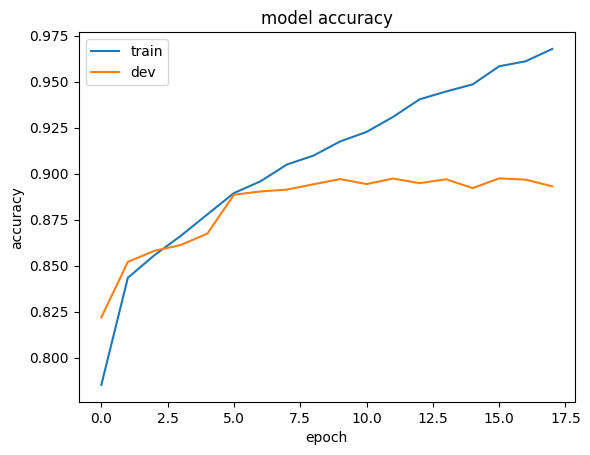

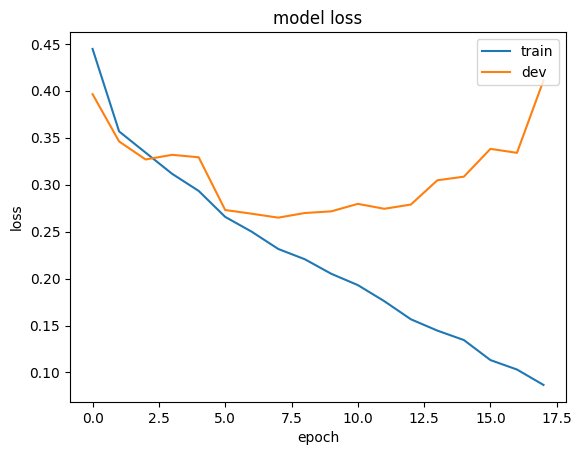

In [43]:
%matplotlib inline
import matplotlib.pyplot as plt

# summarize history for accuracy
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train', 'dev'], loc='upper left')
plt.show()
# summarize history for loss
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'dev'], loc='upper right')
plt.show()

In [44]:
from sklearn.metrics import classification_report

# Assuming predictions are probabilities, convert them to binary labels
predictions = bigru.predict(np.array(X_dev))

313/313 [==============================] - 319s 1s/step


In [45]:
# Print classification report
predictions = np.array([[1] if pred >= 0.5 else [0] for pred in predictions])

print(classification_report(y_dev, predictions))

              precision    recall  f1-score   support

           0       0.89      0.89      0.89      4957
           1       0.90      0.89      0.89      5043

    accuracy                           0.89     10000
   macro avg       0.89      0.89      0.89     10000
weighted avg       0.89      0.89      0.89     10000



313/313 [==============================] - 175s 559ms/step


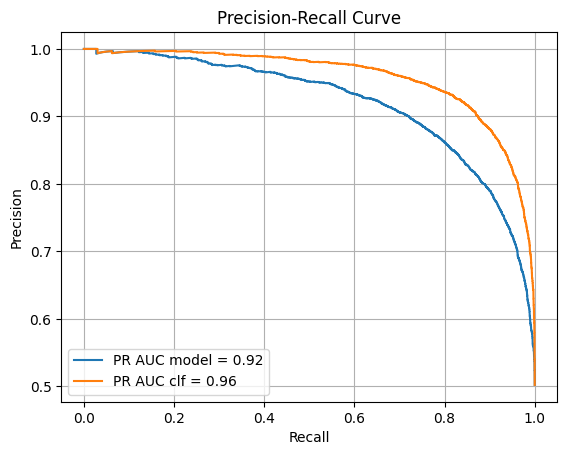

In [172]:
# Calculate model predictions
y_pred = bigru.predict(np.array(X_test))
precision, recall, thresholds = precision_recall_curve(y_test, y_pred)

# Compute PR AUC
pr_auc = auc(recall, precision)

# Plot the PR curve for our model
plt.figure()
plt.plot(recall, precision, label='PR AUC model = %0.2f' % pr_auc)
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend(loc='lower left')


# Predict probabilities
probs = clf.predict_proba(X_test_svd)[:, 1]

# Calculate precision and recall
precision, recall, thresholds = precision_recall_curve(y_test, probs)

# Calculate area under the curve (AUC) for PR curve
pr_auc = auc(recall, precision)

# Plot PR curve for baseline model
plt.plot(recall, precision, label=f'PR AUC clf = {pr_auc:.2f}')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend(loc='lower left')
plt.grid(True)

del bigru


###  Build BiLSTM + Linear self-attention


In [45]:

LSTM_SIZE = 300
DENSE = 1000

# create empty sequential model
bilstm_self = tf.keras.Sequential()
bilstm_self.add(tf.keras.layers.Input(shape=(1,), dtype=tf.string))
bilstm_self.add(vectorizer)
# add an embedding layer
bilstm_self.add(tf.keras.layers.Embedding(MAX_WORDS, EMBEDDING_DIM, weights=[embedding_matrix],
                    input_length=MAX_SEQUENCE_LENGTH, mask_zero=True, trainable=False))

# Use 0.33 dropout probabillity
bilstm_self.add(tf.keras.layers.Dropout(0.33))
# add a bidirectional lstm layer with 0.33 variational (recurrent) dropout
bilstm_self.add(tf.keras.layers.Bidirectional(tf.keras.layers.LSTM(LSTM_SIZE, return_sequences=True, recurrent_dropout = 0.33)))
bilstm_self.add(tf.keras.layers.Dropout(0.33))
# Add linear self-attention layer
# mlp_layers=0 ==>  # sum(softmax(WX + b) * X)
bilstm_self.add(SelfAttention(mlp_layers=0))


# add an MLP with 1 hidden layer
bilstm_self.add(tf.keras.layers.Dense(units=DENSE, activation='relu' ))
bilstm_self.add(tf.keras.layers.Dropout(0.33))
bilstm_self.add(tf.keras.layers.Dense(1, activation='sigmoid'))
print(bilstm_self.summary())

bilstm_self.compile(loss='binary_crossentropy',
               optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
               metrics=["accuracy"])

# train_data = np.array([[" ".join(x_train)] for x_train in X_train_tokenized])
# val_data = np.array([[" ".join(x_val)] for x_val in X_val_tokenized])

history2 = bilstm_self.fit(np.array(X_train), y_train,
              validation_data=(np.array(X_dev), y_dev),
              batch_size=256,
              epochs=10,
              shuffle=True,
              callbacks=[Metrics(valid_data=(np.array(X_dev), y_dev))])

Model: "sequential_2"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 text_vectorization (TextVec  (None, 64)               0         
 torization)                                                     
                                                                 
 embedding_1 (Embedding)     (None, 64, 300)           30000000  
                                                                 
 dropout_6 (Dropout)         (None, 64, 300)           0         
                                                                 
 bidirectional_1 (Bidirectio  (None, 64, 600)          1442400   
 nal)                                                            
                                                                 
 dropout_7 (Dropout)         (None, 64, 600)           0         
                                                                 
 self_attention (SelfAttenti  (None, 600)             

/home/meizeus/miniconda3/envs/tf_env/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1497: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


313/313 [==============================] - 125s 398ms/step
 — val_f1: 0.332334 — val_precision: 0.249101 — val_recall: 0.499100
118/118 [==============================] - 350s 3s/step - loss: 0.4623 - accuracy: 0.7822 - val_loss: 0.4277 - val_accuracy: 0.7984 - val_f1: 0.3323 - val_recall: 0.4991 - val_precision: 0.2491
Epoch 3/10


/home/meizeus/miniconda3/envs/tf_env/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1497: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


313/313 [==============================] - 201s 643ms/step
 — val_f1: 0.332334 — val_precision: 0.249101 — val_recall: 0.499100
118/118 [==============================] - 458s 4s/step - loss: 0.4312 - accuracy: 0.7983 - val_loss: 0.4263 - val_accuracy: 0.7955 - val_f1: 0.3323 - val_recall: 0.4991 - val_precision: 0.2491
Epoch 4/10


...

/home/meizeus/miniconda3/envs/tf_env/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1497: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


313/313 [==============================] - 426s 1s/step
 — val_f1: 0.332334 — val_precision: 0.249101 — val_recall: 0.499100
118/118 [==============================] - 737s 6s/step - loss: 0.3671 - accuracy: 0.8352 - val_loss: 0.3590 - val_accuracy: 0.8336 - val_f1: 0.3323 - val_recall: 0.4991 - val_precision: 0.2491
Epoch 10/10


/home/meizeus/miniconda3/envs/tf_env/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1497: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


313/313 [==============================] - 290s 926ms/step
 — val_f1: 0.332334 — val_precision: 0.249101 — val_recall: 0.499100
118/118 [==============================] - 573s 5s/step - loss: 0.3584 - accuracy: 0.8394 - val_loss: 0.3587 - val_accuracy: 0.8376 - val_f1: 0.3323 - val_recall: 0.4991 - val_precision: 0.2491


/home/meizeus/miniconda3/envs/tf_env/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1497: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Training History

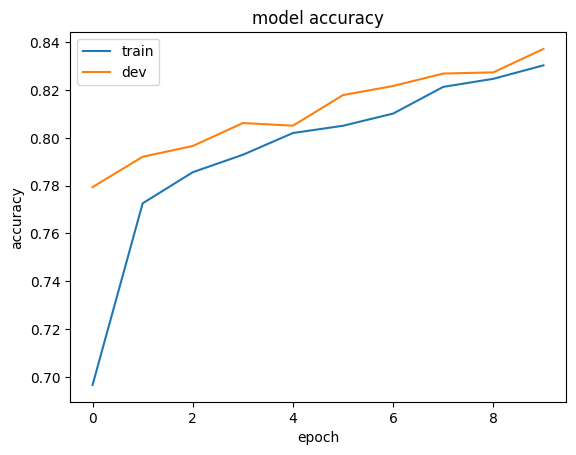

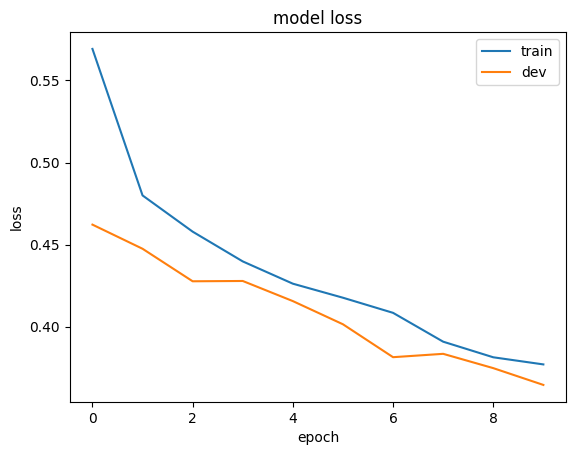

In [46]:
%matplotlib inline
import matplotlib.pyplot as plt

# summarize history for accuracy
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train', 'dev'], loc='upper left')
plt.show()
# summarize history for loss
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'dev'], loc='upper right')
plt.show()

In [47]:
from sklearn.metrics import classification_report

# Assuming predictions are probabilities, convert them to binary labels
predictions = np.argmax(bilstm_self.predict(np.array(X_dev)), axis=-1)

313/313 [==============================] - 33s 105ms/step


In [48]:
# Print classification report
print(y_dev)
print(classification_report(y_dev, predictions))

14434    0
8614     1
7108     0
12773    1
18529    1
        ..
16284    1
16964    0
10390    1
5860     0
20795    0
Name: sentiment, Length: 10000, dtype: int64
              precision    recall  f1-score   support

           0       0.50      1.00      0.67      4991
           1       0.00      0.00      0.00      5009

    accuracy                           0.50     10000
   macro avg       0.25      0.50      0.33     10000
weighted avg       0.25      0.50      0.33     10000



/home/meizeus/miniconda3/envs/tf_env/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1497: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/home/meizeus/miniconda3/envs/tf_env/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1497: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/home/meizeus/miniconda3/envs/tf_env/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1497: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.cap